# University Lab: Advanced Deep Learning for Sentiment Engineering
**Course:** AI 301 - Deep Learning & Computer Vision  
**Duration:** 60 Minutes | **Dataset:** FER-2013 (Directory Format)

--- 

## 1. Objective
In this lab, you will engineer a multi-stage Convolutional Neural Network (CNN) to interpret human emotional signals. We shift from viewing AI as a 'black box' to treating it as a series of complex spatial filters.

## 2. Architecture: CNNs as Spatial Filter Banks
* **Convolutional Layers:** These are the 'sensors' of the network. Each $3 \times 3$ or $5 \times 5$ kernel learns to respond to specific frequencies—edges, curves, or textures.
* **Batch Normalization:** This acts as a signal regulator, ensuring that the 'voltage' (gradients) remains stable as it propagates through deep layers.
* **Pooling:** Reduces spatial resolution to extract the dominant feature, providing robustness to head tilt and position.

## 3. Data Engineering & Streaming
We utilize the directory-based structure of FER-2013. Instead of loading thousands of images into memory, we create a streaming pipeline.

In [15]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("msambare/fer2013", output_dir="./dataset")

print("Path to dataset files:", path)

# Update your directory paths to point to the downloaded location
TRAIN_DIR = os.path.join(path, 'train')
TEST_DIR = os.path.join(path, 'test')

Path to dataset files: ./dataset


In [16]:
# Check available devices

# Source - https://stackoverflow.com/a/44829372
# Posted by pfm, modified by community. See post 'Timeline' for change history
# Retrieved 2026-04-21, License - CC BY-SA 4.0

from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())


[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 11384013832116944889
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 9190178816
locality {
  bus_id: 1
  links {
  }
}
incarnation: 6532382585801490916
physical_device_desc: "device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:29:00.0, compute capability: 8.6"
xla_global_id: 416903419
]


I0000 00:00:1776779098.628622 1268534 gpu_device.cc:2043] Created device /device:GPU:0 with 8764 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:29:00.0, compute capability: 8.6


In [17]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator


# Signal Augmentation Pipeline
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(48, 48),
    batch_size=64,
    color_mode='grayscale',
    class_mode='categorical',
    shuffle=True
)

validation_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(48, 48),
    batch_size=64,
    color_mode='grayscale',
    class_mode='categorical',
    shuffle=False
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


## 4. Architectural Implementation
We implement a modular, high-depth architecture.

In [18]:
from tensorflow.keras import layers, models, optimizers

def build_advanced_model():
    model = models.Sequential()

    # Block 1: Edges
    model.add(layers.Conv2D(32, (3, 3), padding='same', input_shape=(48, 48, 1), activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Dropout(0.25))

    # Block 2: Complex Shapes
    model.add(layers.Conv2D(128, (5, 5), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Dropout(0.25))

    # Fully Connected Logic
    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(7, activation='softmax'))

    model.compile(optimizer=optimizers.Adam(learning_rate=0.001), 
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model = build_advanced_model()
model.summary()

/home/eslamallam/Projects/python/sentiment-analysis/.pixi/envs/default/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 24, 24, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,946,311 (18.87 MB)

 Trainable params: 4,945,351 (18.87 MB)

 Non-trainable params: 960 (3.75 KB)

## 5. Optimization Loop & Transient Analysis
We use adaptive callbacks to ensure smooth convergence.

In [19]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, verbose=1)
early_stopper = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    train_generator,
    epochs=15,
    validation_data=validation_generator,
    callbacks=[lr_reducer, early_stopper]
)

Epoch 1/15


I0000 00:00:1776779101.226768 1268895 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_165728__.60


283/449 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.2258 - loss: 2.3911

I0000 00:00:1776779110.759307 1268896 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_165728__.60


449/449 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.2942 - loss: 1.9758 - val_accuracy: 0.1333 - val_loss: 3.6384 - learning_rate: 0.0010
Epoch 2/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.3978 - loss: 1.5663 - val_accuracy: 0.4207 - val_loss: 1.4972 - learning_rate: 0.0010
Epoch 3/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.4549 - loss: 1.4211 - val_accuracy: 0.5093 - val_loss: 1.2998 - learning_rate: 0.0010
Epoch 4/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.4846 - loss: 1.3506 - val_accuracy: 0.5247 - val_loss: 1.2522 - learning_rate: 0.0010
Epoch 5/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.5012 - loss: 1.3100 - val_accuracy: 0.5352 - val_loss: 1.2476 - learning_rate: 0.0010
Epoch 6/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.5132 - loss: 1.2825 - val_accuracy: 0.4848 - val_loss: 1.3587 - learning_rate: 0.0010
Epoch 7/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.5218 - loss: 1.2578

## 6. Diagnostic Evaluation: Confusion Matrix
Analyze 'Emotional Cross-talk'—where does the model fail?

113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step


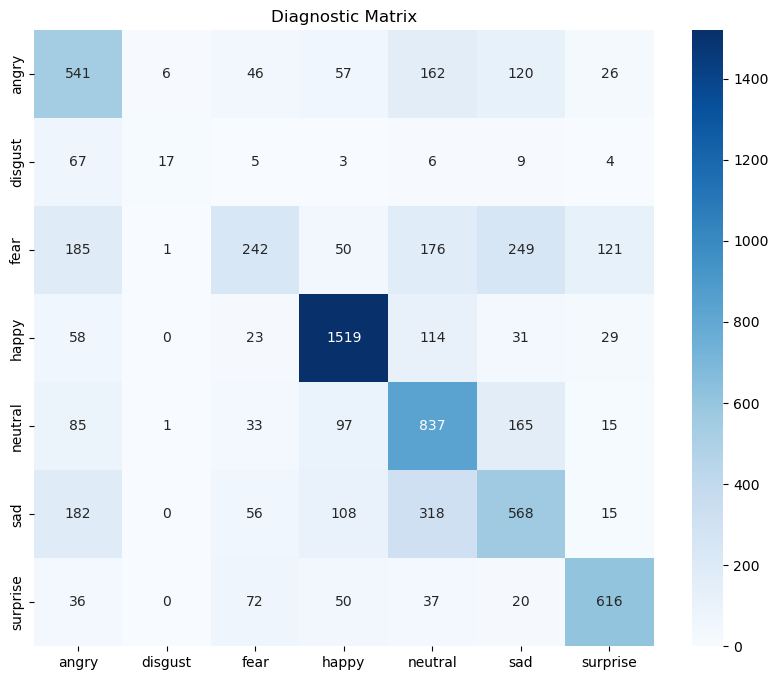

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

Y_pred = model.predict(validation_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = validation_generator.classes
class_labels = list(validation_generator.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels, cmap='Blues')
plt.title('Diagnostic Matrix')
plt.show()

## 7. Real-Time Deployment
Apply the trained weights to a live video stream.

In [21]:
import cv2

cap = cv2.VideoCapture(0)
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

while True:
    ret, frame = cap.read()
    if not ret: break
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    for (x, y, w, h) in faces:
        roi = cv2.resize(gray[y:y+h, x:x+w], (48, 48))
        roi = roi.astype('float32') / 255.0
        roi = np.expand_dims(np.expand_dims(roi, -1), 0)
        
        prediction = model.predict(roi, verbose=0)
        label = class_labels[np.argmax(prediction)]
        
        cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)
        cv2.putText(frame, label, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)

    cv2.imshow('Live Sentiment Analyzer', frame)
    if cv2.waitKey(1) & 0xFF == ord('q'): break

cap.release()
cv2.destroyAllWindows()

QObject::moveToThread: Current thread (0x55e37e324180) is not the object's thread (0x55e3825ac360).
Cannot move to target thread (0x55e37e324180)

QObject::moveToThread: Current thread (0x55e37e324180) is not the object's thread (0x55e3825ac360).
Cannot move to target thread (0x55e37e324180)

QObject::moveToThread: Current thread (0x55e37e324180) is not the object's thread (0x55e3825ac360).
Cannot move to target thread (0x55e37e324180)

QObject::moveToThread: Current thread (0x55e37e324180) is not the object's thread (0x55e3825ac360).
Cannot move to target thread (0x55e37e324180)

QObject::moveToThread: Current thread (0x55e37e324180) is not the object's thread (0x55e3825ac360).
Cannot move to target thread (0x55e37e324180)

QObject::moveToThread: Current thread (0x55e37e324180) is not the object's thread (0x55e3825ac360).
Cannot move to target thread (0x55e37e324180)

QObject::moveToThread: Current thread (0x55e37e324180) is not the object's thread (0x55e3825ac360).
Cannot move to tar

---
## Take-Home Assignment: Adversarial Feature Sabotage
**Task 1: Occlusion Sensitivity** 
Make a 'Happy' face. Now cover your mouth. Does the prediction shift? Analyze why the eyes alone might not be a 'strong enough signal' for this specific architecture.

**Task 2: Architecture Tuning** 
Remove the `BatchNormalization` layers. Record the convergence speed. Explain how normalization acts as a 'stabilizer' in deep signals.

**Task 3: Threshold Tuning** 
Adjust the live code to only show a label if confidence $> 0.8$. Which emotions are the most 'uncertain'?